<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Microstructure: the EDGE spread estimator
    </h1>
  </div>
</div>

The effective **bid-ask spread** must be estimated from prices when quotes
are unavailable. The classic low-frequency estimators use limited price
information: **Roll (1984)** uses only close-to-close serial covariance and
returns an *invalid* (negative) estimate whenever that covariance is positive;
**Corwin-Schultz (2012)** uses the two-day high-low range. The **EDGE**
estimator (Ardia-Guidotti-Kroencke 2024) pools all four OHLC prices and corrects
for discrete, infrequent trading, so it has lower bias and variance and **never
returns a negative point estimate**.

*Baseline -> where it breaks -> EDGE -> when to use.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Features: edge_estimator, corwin_schultz_estimator
using CSV, DataFrames

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. Real intraday OHLC (committed AAPL 1-minute snapshot)
FRED has no intraday volume/quotes, so we use the committed AAPL 1-minute OHLCV
snapshot. EDGE needs only the open, high, low and close.

In [2]:
df = CSV.read(joinpath(@__DIR__, "..", "Data", "AAPL_OHLCV_1m_Data.csv"), DataFrame)
o = Float64.(df.Open); h = Float64.(df.High); l = Float64.(df.Low); c = Float64.(df.Close)
println(nrow(df), " one-minute bars, ", df.Datetime[1], " .. ", df.Datetime[end])
edge_all = edge_estimator(o, h, l, c)
println("Whole-sample EDGE spread estimate: ", round(edge_all * 1e4, digits = 2), " bps")

1949 one-minute bars, 2022-08-22 09:30:00 .. 2022-08-26 16:00:00
Whole-sample EDGE spread estimate: 0.96 bps


## 2. Rolling EDGE vs the Corwin-Schultz baseline
We estimate the spread on consecutive 60-minute windows with both methods. The
Roll estimator (close-to-close) is shown as the fraction of windows it would
flag *invalid* (a negative squared spread).

In [3]:
W = 60
edges = Float64[]; cs = Float64[]; roll_invalid = 0; nwin = 0
for s in 1:W:(length(c) - W)
    rng = s:(s + W - 1)
    push!(edges, edge_estimator(o[rng], h[rng], l[rng], c[rng]))
    csv = corwin_schultz_estimator(h[rng], l[rng], 20)
    push!(cs, mean(filter(!isnan, csv)))
    # Roll (1984): spread = 2*sqrt(-cov(Δp_t, Δp_{t-1})); invalid when cov > 0.
    dp = diff(c[rng])
    roll_cov = cov(dp[2:end], dp[1:end-1])
    roll_invalid += (roll_cov > 0); nwin += 1
end
println("EDGE negative estimates : ", count(<(0), edges), " / ", length(edges))
println("Roll INVALID windows    : ", roll_invalid, " / ", nwin,
        "  (", round(100roll_invalid / nwin, digits = 1), "% unusable)")

EDGE negative estimates : 0 / 32
Roll INVALID windows    : 19 / 32  (59.4% unusable)


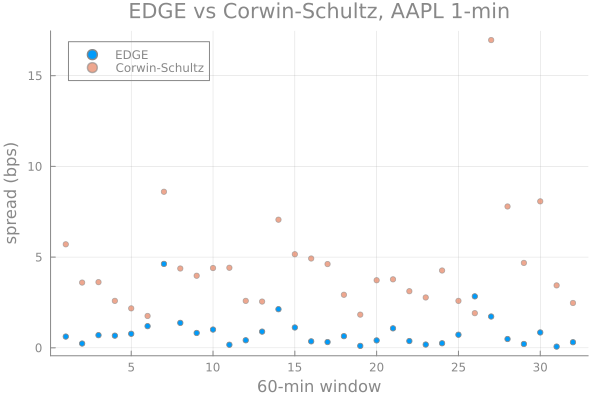

In [4]:
scatter(1:length(edges), edges .* 1e4; label = "EDGE", ms = 3,
        xlabel = "60-min window", ylabel = "spread (bps)",
        title = "EDGE vs Corwin-Schultz, AAPL 1-min")
scatter!(1:length(cs), cs .* 1e4; label = "Corwin-Schultz", ms = 3, alpha = 0.6)

## When to use / when NOT (from `appraisals/03_verdict.md`)
**Prefer EDGE over Roll and Abdi-Ranaldo for low-frequency spread estimation in
all regimes; over Corwin-Schultz at small spreads** (the edge narrows at very
high illiquidity and very large spreads). Roll returns ~30-40% invalid estimates
on real data; EDGE never returns a negative point estimate by construction. EDGE
returns `NaN` only on degenerate input (fewer than three observations, fewer than
two traded periods, zero variance).